In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import optuna
from stable_baselines3 import PPO
import os

# --- Configuration ---
CONFIG = {
    "WINDOW_SIZE": 60,
    "TX_COST_BPS": 0.0010,
    "RISK_AVERSION": 4.0,
    "SMA_WINDOW": 50,
    "RSI_WINDOW": 14
}   

def load_real_data(tickers=None, benchmark='QQQ', start='2015-01-01', end='2025-10-31'):
    if tickers is None:
        # Tech + Defensive Mix
        tickers = ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG', 'GLD', 'TLT', 'XLE', 'XLP']
    
    all_tickers = tickers + [benchmark]
    print(f"Downloading {len(all_tickers)} assets...")
    raw_data = yf.download(all_tickers, start=start, end=end, progress=False, auto_adjust=True)
    
    if isinstance(raw_data.columns, pd.MultiIndex):
        try:
            df = raw_data['Close'].copy()
        except KeyError:
            df = raw_data['close'].copy()
    else:
        df = raw_data.copy()

    # --- SAFETY CHECK ---
    # Forward fill to handle holidays
    df = df.ffill()
    # Only drop rows if a ticker is missing for >5% of the time
    # This prevents one bad ticker from deleting your whole dataset
    valid_cols = df.isnull().mean() < 0.05
    df = df.loc[:, valid_cols]
    df = df.dropna() 
    
    # Reorder: Keep benchmark with its original name
    asset_cols = [t for t in tickers if t in df.columns]
    # Verify benchmark is still present
    if benchmark not in df.columns:
        raise ValueError(f"Benchmark '{benchmark}' not found in data after cleaning!")
    final_cols = asset_cols + [benchmark]
    return df[final_cols]

class FinancialFeatureEngineer:
    def preprocess_data(self, df, benchmark_col=None):
        """
        Preprocess financial data into features.
        
        Args:
            df: DataFrame with asset prices and benchmark
            benchmark_col: Name of benchmark column (if None, auto-detect as last column)
        """
        data = df.copy()
        
        # Auto-detect benchmark: assume it's the last column if not specified
        if benchmark_col is None:
            benchmark_col = df.columns[-1]
        
        asset_cols = [c for c in data.columns if c != benchmark_col]
        
        # 1. Log Returns (Raw Movement)
        # Essential for the agent to know "Did we go up or down today?"
        log_ret = np.log(data[asset_cols] / data[asset_cols].shift(1)).fillna(0)
        
        # 2. Volatility (Z-Score)
        # "Is this asset acting crazy?"
        roll_std = log_ret.rolling(20).std()
        norm_vol = (roll_std - roll_std.rolling(252).mean()) / (roll_std.rolling(252).std() + 1e-8)
        
        # 3. RSI (Momentum)
        # "Is it overbought?"
        delta = data[asset_cols].diff()
        gain = (delta.where(delta > 0, 0)).rolling(CONFIG["RSI_WINDOW"]).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(CONFIG["RSI_WINDOW"]).mean()
        rs = gain / (loss + 1e-8)
        norm_rsi = (100 - (100 / (1 + rs)) - 50) / 100
        
        # 4. Correlation to Market (Systemic Risk)
        # "Is it following the herd?"
        mkt_ret = data[benchmark_col].pct_change()
        corr = log_ret.rolling(CONFIG["WINDOW_SIZE"]).corr(mkt_ret)
        
        # 5. Distance from Trend (SMA) -- V2 CRITICAL FEATURE
        # "Is it in an uptrend?"
        # This aligns the Agent's brain with your Board's logic
        sma_50 = data[asset_cols].rolling(CONFIG["SMA_WINDOW"]).mean()
        dist_sma = (data[asset_cols] / sma_50) - 1.0
        
        # --- CLEANUP ---
        norm_vol = norm_vol.fillna(0).clip(-3, 3)
        norm_rsi = norm_rsi.fillna(0)
        corr = corr.fillna(0)
        dist_sma = dist_sma.fillna(0).clip(-0.5, 0.5)
        
        # Stack 5 Features (Time, Assets, 5)
        features = np.stack([
            norm_vol.values, 
            norm_rsi.values, 
            corr.values, 
            dist_sma.values,  # Index 3
            log_ret.values    # Raw returns helpful for agent
        ], axis=-1)
        
        # Verify feature count matches expected (5 features)
        assert features.shape[2] == 5, f"Expected 5 features, got {features.shape[2]}"
        
        return features, data[asset_cols].values, data[benchmark_col].values

# --- Load & Process ---
df = load_real_data()
# Get benchmark name from the loaded data (last column)
benchmark_name = df.columns[-1]
print(f"Using benchmark: {benchmark_name}")

engineer = FinancialFeatureEngineer()
features, prices, benchmark = engineer.preprocess_data(df, benchmark_col=benchmark_name)

# Split
split = int(len(df) * 0.8)
feat_train, feat_test = features[:split], features[split:]
price_train, price_test = prices[:split], prices[split:]
bench_train, bench_test = benchmark[:split], benchmark[split:]

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using benchmark: QQQ


In [2]:
class PortfolioRebalanceEnv(gym.Env):
    def __init__(self, price_data, features_data, benchmark_data, 
                 initial_balance=100_000, lookback_window=None):
        if lookback_window is None:
            lookback_window = CONFIG["WINDOW_SIZE"]
        super().__init__()
        self.prices = price_data
        self.features = features_data
        self.benchmark = benchmark_data
        self.n_assets = self.prices.shape[1]
        self.n_features = self.features.shape[2]
        self.lookback_window = lookback_window
        
        # Verify feature count matches expected (5 features)
        assert self.n_features == 5, f"Expected 5 features, got {self.n_features}. Check feature engineering."
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(self.n_assets + 1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-5, high=5, shape=(lookback_window, self.n_assets, self.n_features), dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.lookback_window
        self.cash = 100_000.0
        self.shares = np.zeros(self.n_assets)
        self.portfolio_value = 100_000.0
        self.history_nav = [100_000.0]
        return self._get_obs(), {}

    def step(self, action):
        # Weights
        exp_action = np.exp(action)
        weights = exp_action / np.sum(exp_action)
        
        # Rebalance
        current_prices = self.prices[self.current_step]
        target_val = self.portfolio_value * weights[:-1]
        current_holdings = self.shares * current_prices
        cost = np.sum(np.abs(target_val - current_holdings)) * CONFIG["TX_COST_BPS"]
        
        self.cash = (self.portfolio_value * weights[-1]) - cost
        self.shares = target_val / current_prices
        
        # Forward 20 Days
        daily_ret = []
        steps = min(20, len(self.prices) - self.current_step - 1)
        for _ in range(steps):
            self.current_step += 1
            val = self.cash + np.sum(self.shares * self.prices[self.current_step])
            daily_ret.append(np.log(val / self.history_nav[-1]))
            self.history_nav.append(val)
            
        self.portfolio_value = self.history_nav[-1]
        
        # Reward
        bench_slice = self.benchmark[self.current_step-20:self.current_step]
        mkt_vol = np.std(bench_slice) if len(bench_slice) > 1 else 0.01
        
        lam = CONFIG["RISK_AVERSION"] + ((mkt_vol - 0.015)*100 if mkt_vol > 0.015 else 0)
        r = np.array(daily_ret)
        downside = np.std(r[r<0]) if len(r[r<0]) > 0 else 0.0
        reward = np.sum(r) - (lam * downside)
        
        done = self.current_step >= len(self.prices) - 2
        return self._get_obs(), reward, done, False, {}

    def _get_obs(self):
        return self.features[self.current_step-self.lookback_window : self.current_step].astype(np.float32)


class BearEnv(PortfolioRebalanceEnv):
    """
    Bear Environment: Paranoid agent focused on minimizing drawdowns.
    Reward = Returns - Heavy Penalty for Volatility/Drawdowns
    """
    def step(self, action):
        # Use parent's step logic but override reward calculation
        obs, reward, done, truncated, info = super().step(action)
        
        # Override reward: Bear is terrified of volatility
        # Calculate more aggressive penalty
        bench_slice = self.benchmark[self.current_step-20:self.current_step]
        mkt_vol = np.std(bench_slice) if len(bench_slice) > 1 else 0.01
        
        # Bear uses MUCH higher risk aversion (2x-3x normal)
        bear_lambda = CONFIG["RISK_AVERSION"] * 2.5  # Much more paranoid
        if mkt_vol > 0.015:
            bear_lambda += (mkt_vol - 0.015) * 200  # Even more sensitive to volatility
        
        # Get daily returns from history
        if len(self.history_nav) > 1:
            recent_returns = np.diff(np.log(self.history_nav[-21:])) if len(self.history_nav) >= 21 else np.diff(np.log(self.history_nav))
            r = np.array(recent_returns)
            downside = np.std(r[r<0]) if len(r[r<0]) > 0 else 0.001
            # Bear reward: returns minus heavy penalty
            bear_reward = np.sum(r) - (bear_lambda * downside)
        else:
            bear_reward = reward  # Fallback
        
        return obs, bear_reward, done, truncated, info


# --- Training ---
print("Training Agents...")

# Bull (Return Focused)
train_env_bull = PortfolioRebalanceEnv(price_train, feat_train, bench_train)
model_bull = PPO("MlpPolicy", train_env_bull, verbose=0)
model_bull.learn(total_timesteps=30_000)
model_bull.save("agent_bull")
print("Bull Agent Trained and Saved.")

# Bear (Risk Focused)
env_bear = BearEnv(price_train, feat_train, bench_train)
model_bear = PPO("MlpPolicy", env_bear, verbose=0)
model_bear.learn(total_timesteps=30_000)
model_bear.save("agent_bear")
print("Bear Agent Trained and Saved.")

# Sniper (Balanced)
train_env_sniper = PortfolioRebalanceEnv(price_train, feat_train, bench_train)
model_sniper = PPO("MlpPolicy", train_env_sniper, verbose=0)
model_sniper.learn(total_timesteps=50_000)
model_sniper.save("agent_sniper")
print("Sniper Agent Trained and Saved.")

print("All Agents Ready.")

Training Agents...
Bull Agent Trained and Saved.
Bear Agent Trained and Saved.
Sniper Agent Trained and Saved.
All Agents Ready.


In [3]:
# Pre-compute Logits (Massive Speedup)
print("Pre-computing logits...")
# Create a shared environment for accessing features and benchmark
train_env = PortfolioRebalanceEnv(price_train, feat_train, bench_train)

indices = range(CONFIG["WINDOW_SIZE"], len(price_train)-22, 20)
w_bull, w_bear, w_sniper = [], [], []
precalc_signals = [] # Store Vol/RSI/SMA here to avoid calculating inside the loop

# We pre-calculate the technicals ONCE so the optimization loop is pure math
for i in indices:
    obs = train_env.features[i-CONFIG["WINDOW_SIZE"]:i]
    
    # Agents
    w_bull.append(model_bull.predict(obs, deterministic=True)[0])
    w_bear.append(model_bear.predict(obs, deterministic=True)[0])
    w_sniper.append(model_sniper.predict(obs, deterministic=True)[0])
    
    # Signals
    b_short = train_env.benchmark[i-5:i]
    vol = pd.Series(b_short).pct_change().std() if len(b_short)>1 else 0.01
    
    feat_slice = train_env.features[i-CONFIG["WINDOW_SIZE"]:i]
    # Feature Index 1: RSI (normalized)
    raw_rsi = (feat_slice[-1,:,1] * 100) + 50
    avg_rsi = np.mean(raw_rsi)
    
    # Feature Index 3: Dist_SMA (Distance from SMA)
    # Dist_SMA > 0 implies Price > SMA
    latest_features = feat_slice[-1]  # (Assets, Features)
    # Check if majority of assets are above their SMA
    assets_trending = np.mean(latest_features[:, 3]) > 0
    
    precalc_signals.append((vol, avg_rsi, assets_trending))

# Convert to Arrays
w_bull = np.array(w_bull); w_bear = np.array(w_bear); w_sniper = np.array(w_sniper)

class TurboLogicEngine:
    def __init__(self, prices, w_bull, w_bear, w_sniper, signals, indices):
        self.prices = prices
        self.w_bull = w_bull
        self.w_bear = w_bear
        self.w_sniper = w_sniper
        self.signals = signals # List of (vol, rsi, sma)
        self.indices = indices
        self.n_assets = prices.shape[1]
        
    def _softmax(self, x):
        e = np.exp(x - np.max(x))
        return e / e.sum()

    def run(self, panic_vol, reb_thresh, reentry_alloc):
        """
        reentry_alloc: Percentage of capital to deploy during Re-entry (0.1 to 0.9)
        """
        cash = 100_000.0
        shares = np.zeros(self.n_assets)
        hist = []
        
        for ptr, i in enumerate(self.indices):
            # Retrieve pre-calced signals
            vol, rsi, assets_trending = self.signals[ptr]
            
            # 1. Determine Target Weights
            # Softmax logits
            wb = self._softmax(self.w_bull[ptr])
            ws = self._softmax(self.w_sniper[ptr])
            wbr = self._softmax(self.w_bear[ptr])
            
            regime = "GROWTH"
            
            if vol > panic_vol:
                if rsi < 30 or assets_trending:
                    # RE-ENTRY: Use Optimization param 'reentry_alloc'
                    # Normalize asset weights
                    aws = ws[:-1] / (np.sum(ws[:-1]) + 1e-9)
                    # Scale assets by alloc, rest to cash
                    tw = np.append(aws * reentry_alloc, (1.0 - reentry_alloc))
                    regime = "RE-ENTRY"
                else:
                    # CRASH: 100% Cash
                    tw = np.zeros_like(ws); tw[-1] = 1.0
                    regime = "CRASH"
            elif vol > 0.012:
                tw = (0.5*ws) + (0.25*wbr) + (0.25*wb)
                regime = "CHOPPY"
            else:
                tw = (0.7*wb) + (0.3*ws)

            # 2. Rebalance Wrapper
            p = self.prices[i]
            curr_val = cash + np.sum(shares * p)
            
            if curr_val > 0:
                cw = np.append((shares * p) / curr_val, cash / curr_val)
            else:
                cw = np.zeros_like(tw); cw[-1] = 1.0
                
            # Lower inertia if crashing or re-entering
            act_thresh = 0.01 if "CRASH" in regime or "RE-ENTRY" in regime else reb_thresh
            
            if np.sum(np.abs(tw - cw)) > act_thresh:
                t_val = curr_val * tw
                cost = np.sum(np.abs(t_val[:-1] - (shares * p))) * CONFIG["TX_COST_BPS"]
                cash = t_val[-1] - cost
                shares = t_val[:-1] / p
                
            # 3. Fast Forward NAV
            end = min(i+20, len(self.prices))
            m_prices = self.prices[i+1 : end+1]
            m_navs = cash + np.dot(m_prices, shares)
            hist.extend(m_navs)
            
        return np.array(hist)

# --- Optuna ---
def objective(trial):
    p_vol = trial.suggest_float("panic_vol", 0.015, 0.035)
    thresh = trial.suggest_float("thresh", 0.02, 0.10)
    # NEW: Let AI decide how aggressive re-entry should be
    re_alloc = trial.suggest_float("reentry_alloc", 0.3, 0.9) 
    
    engine = TurboLogicEngine(price_train, w_bull, w_bear, w_sniper, precalc_signals, indices)
    nav = engine.run(p_vol, thresh, re_alloc)
    
    if len(nav) == 0: return -100
    ret = (nav[-1]/nav[0]) - 1
    dd = np.min((nav / np.maximum.accumulate(nav)) - 1)
    
    # Penalize Drawdown heavily
    if dd < -0.35: return -1.0
    return ret / (abs(dd) + 1e-6)

print("Optimizing V2...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

BP = study.best_params
print(f"Best Params: Panic={BP['panic_vol']:.4f}, Inertia={BP['thresh']:.1%}, Re-Entry Alloc={BP['reentry_alloc']:.1%}")

[I 2025-11-28 11:56:15,414] A new study created in memory with name: no-name-29d55b27-e36a-4522-ba03-b1ade029511b
[I 2025-11-28 11:56:15,417] Trial 0 finished with value: 23.308253875757256 and parameters: {'panic_vol': 0.027765589923964894, 'thresh': 0.03572069626983128, 'reentry_alloc': 0.4547761921809354}. Best is trial 0 with value: 23.308253875757256.
[I 2025-11-28 11:56:15,421] Trial 1 finished with value: 19.867895614528113 and parameters: {'panic_vol': 0.03252873678211681, 'thresh': 0.09117797150408585, 'reentry_alloc': 0.45490511955462826}. Best is trial 0 with value: 23.308253875757256.
[I 2025-11-28 11:56:15,424] Trial 2 finished with value: 21.213167335685117 and parameters: {'panic_vol': 0.03020365138658944, 'thresh': 0.04959100789285776, 'reentry_alloc': 0.7326869420706358}. Best is trial 0 with value: 23.308253875757256.
[I 2025-11-28 11:56:15,427] Trial 3 finished with value: 23.18897674761131 and parameters: {'panic_vol': 0.017459988641048377, 'thresh': 0.0470885194405

Pre-computing logits...
Optimizing V2...


[I 2025-11-28 11:56:15,595] Trial 35 finished with value: 22.504053291414337 and parameters: {'panic_vol': 0.018886220448050123, 'thresh': 0.09070330283316368, 'reentry_alloc': 0.8982630644529952}. Best is trial 23 with value: 33.51489759081539.
[I 2025-11-28 11:56:15,620] Trial 36 finished with value: 18.460881191794986 and parameters: {'panic_vol': 0.016384268759299617, 'thresh': 0.08905382186624498, 'reentry_alloc': 0.4681362392313387}. Best is trial 23 with value: 33.51489759081539.
[I 2025-11-28 11:56:15,625] Trial 37 finished with value: 19.667472676323428 and parameters: {'panic_vol': 0.03499798195372586, 'thresh': 0.07118037463318076, 'reentry_alloc': 0.549154907568599}. Best is trial 23 with value: 33.51489759081539.
[I 2025-11-28 11:56:15,632] Trial 38 finished with value: 24.746863049334394 and parameters: {'panic_vol': 0.01860045474056704, 'thresh': 0.09598021458963558, 'reentry_alloc': 0.4342623458524944}. Best is trial 23 with value: 33.51489759081539.
[I 2025-11-28 11:56

Best Params: Panic=0.0170, Inertia=9.2%, Re-Entry Alloc=30.1%


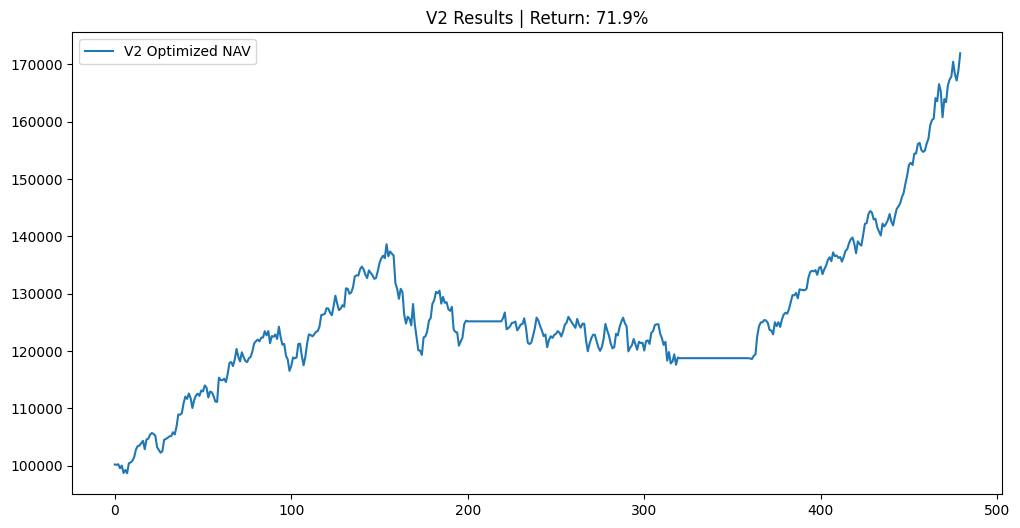

In [4]:
class FinalV2Backtester:
    def __init__(self, bull, bear, sniper, env, p_vol, thresh, re_alloc):
        self.bull = bull; self.bear = bear; self.sniper = sniper
        self.env = env
        self.p_vol = p_vol
        self.thresh = thresh
        self.re_alloc = re_alloc
        self.tx_cost = CONFIG["TX_COST_BPS"]
        
    def _softmax(self, x):
        e = np.exp(x - np.max(x)); return e / e.sum()

    def run(self):
        cash = 100_000.0
        shares = np.zeros(self.env.n_assets)
        history = []
        curr = self.env.lookback_window
        end = len(self.env.prices) - 22
        
        while curr < end:
            # Signals
            b_slice = self.env.benchmark[curr-5:curr]
            vol = pd.Series(b_slice).pct_change().std() if len(b_slice)>1 else 0.01
            if np.isnan(vol): vol = 0.01
            
            obs = self.env.features[curr-CONFIG["WINDOW_SIZE"]:curr]
            # Feature Index 1: RSI (normalized)
            raw_rsi = (obs[-1,:,1] * 100) + 50
            avg_rsi = np.mean(raw_rsi)
            
            # Feature Index 3: Dist_SMA (Distance from SMA)
            # Dist_SMA > 0 implies Price > SMA
            latest_features = obs[-1]  # (Assets, Features)
            # Check if majority of assets are above their SMA
            assets_trending = np.mean(latest_features[:, 3]) > 0
            
            # Agents
            p1, _ = self.bull.predict(obs, deterministic=True)
            p2, _ = self.bear.predict(obs, deterministic=True)
            p3, _ = self.sniper.predict(obs, deterministic=True)
            wb = self._softmax(p1); wbr = self._softmax(p2); ws = self._softmax(p3)
            
            # Logic
            reg = "GROWTH"
            if vol > self.p_vol:
                if avg_rsi < 30 or assets_trending:
                    aws = ws[:-1] / (np.sum(ws[:-1]) + 1e-9)
                    tw = np.append(aws * self.re_alloc, 1.0 - self.re_alloc)
                    reg = "RE-ENTRY"
                else:
                    tw = np.zeros_like(ws); tw[-1] = 1.0
                    reg = "CRASH"
            elif vol > 0.012:
                tw = (0.5*ws) + (0.25*wbr) + (0.25*wb)
                reg = "CHOPPY"
            else:
                tw = (0.7*wb) + (0.3*ws)
                
            # Trade
            p = self.env.prices[curr]
            val = cash + np.sum(shares * p)
            if val > 0: cw = np.append((shares*p)/val, cash/val)
            else: cw = np.zeros_like(tw); cw[-1] = 1.0
            
            act_thresh = 0.01 if reg in ["CRASH", "RE-ENTRY"] else self.thresh
            if np.sum(np.abs(tw - cw)) > act_thresh:
                t_val = val * tw
                cost = np.sum(np.abs(t_val[:-1] - (shares*p))) * self.tx_cost
                cash = t_val[-1] - cost
                shares = t_val[:-1] / p
                
            # Sim
            for t in range(20):
                idx = curr + t + 1
                nav = cash + np.sum(shares * self.env.prices[idx])
                history.append({'step': idx, 'nav': nav, 'regime': reg})
            curr += 20
            
        return pd.DataFrame(history)

# Run Final
test_env = PortfolioRebalanceEnv(price_test, feat_test, bench_test)

tester = FinalV2Backtester(
    model_bull, model_bear, model_sniper, test_env, 
    BP['panic_vol'], BP['thresh'], BP['reentry_alloc']
)
res = tester.run()

# Plot
plt.figure(figsize=(12,6))
plt.plot(res['nav'], label='V2 Optimized NAV')
plt.title(f"V2 Results | Return: {((res['nav'].iloc[-1]/100000)-1)*100:.1f}%")
plt.legend()
plt.show()

In [5]:
# Calculate performance on test data
final_nav = res['nav'].iloc[-1]
initial_nav = 100000  # Starting value
total_return = (final_nav / initial_nav - 1) * 100

# Calculate benchmark performance for comparison
bench_return = (bench_test[-1] / bench_test[0] - 1) * 100

# Calculate additional metrics
nav_series = res['nav']
returns = nav_series.pct_change().dropna()
sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252) if returns.std() > 0 else 0

max_drawdown = ((nav_series / nav_series.cummax()) - 1).min() * 100
calmar_ration = total_return / abs(max_drawdown) if max_drawdown != 0 else 0
print(f"Performance Metrics on Test Data:")
print(f"Total Return: {total_return:.2f}%")
print(f"Benchmark Return: {bench_return:.2f}%")
print(f"Excess Return: {total_return - bench_return:.2f}%")
print(f"Calmar Ratio: {calmar_ration:.2f}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2f}%")
print(f"Final NAV: ${final_nav:,.2f}")


Performance Metrics on Test Data:
Total Return: 71.94%
Benchmark Return: 68.41%
Excess Return: 3.54%
Calmar Ratio: 4.74
Sharpe Ratio: 1.98
Max Drawdown: -15.16%
Final NAV: $171,943.91


Regimes detected: ['GROWTH' 'CHOPPY' 'CRASH']


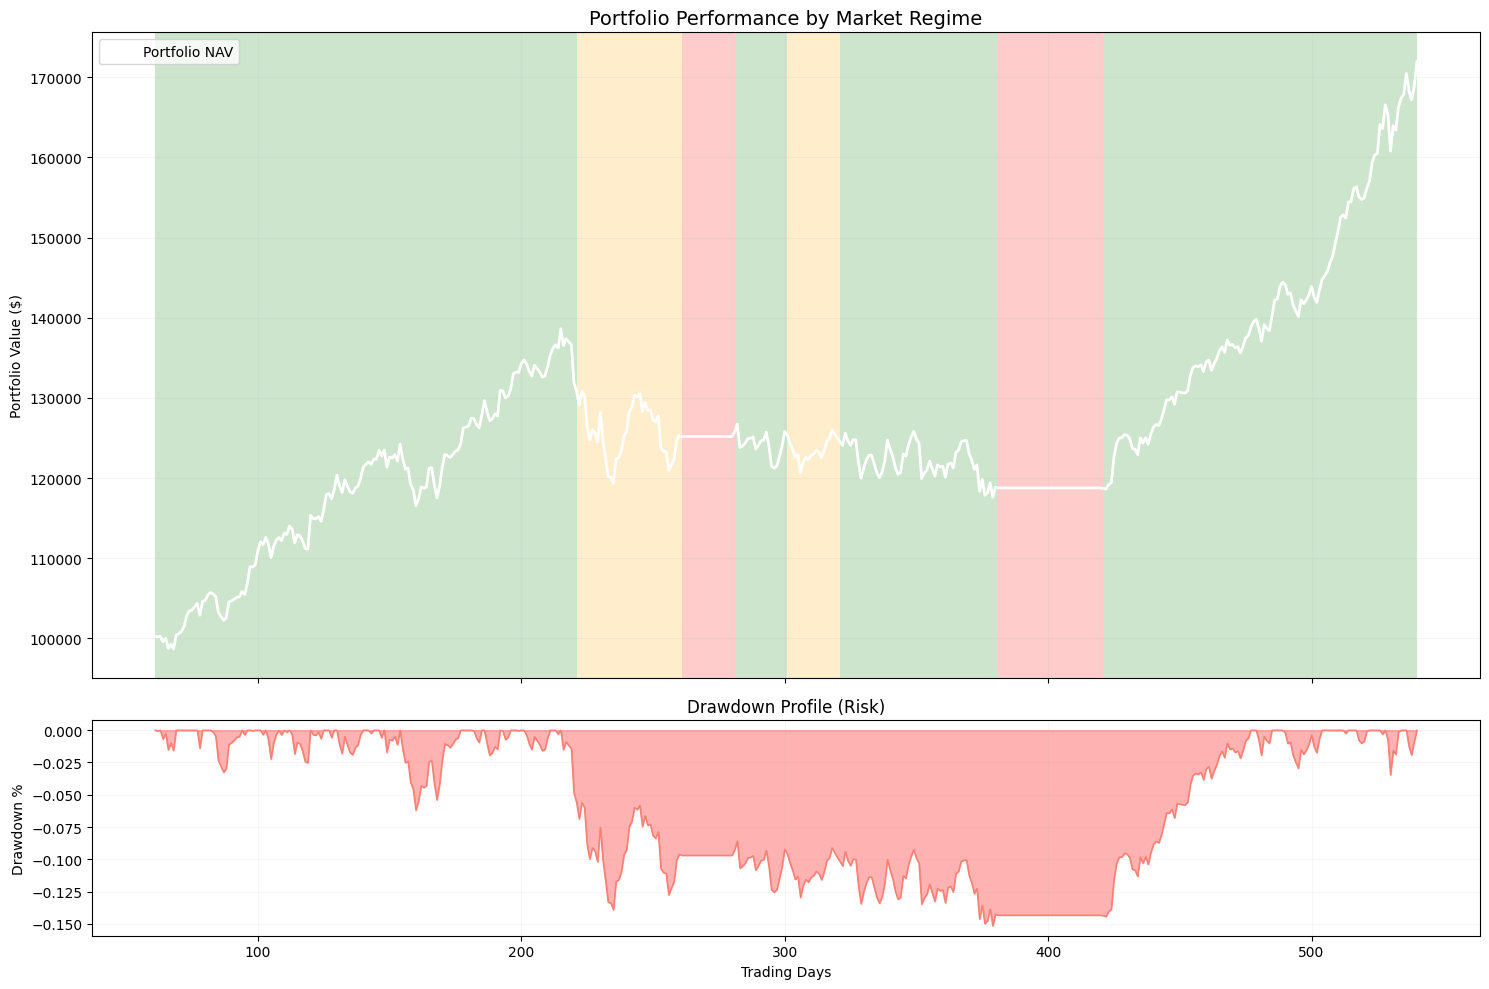

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'res' is your results DataFrame from the FinalV2Backtester

# --- 1. Prepare Data ---
# Extract data
steps = res['step']
nav = res['nav']
regimes = res['regime']

# Calculate Drawdown
running_max = np.maximum.accumulate(nav)
drawdown = (nav / running_max) - 1

# --- 2. Create Dashboard ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# --- TOP PLOT: NAV & REGIMES ---
ax1.plot(steps, nav, color='white', linewidth=2, label='Portfolio NAV')

# Define colors for regimes
# Green = Growth, Orange = Choppy, Red = Crash (Cash), Purple = Re-entry
regime_colors = {
    'GROWTH': 'green', 
    'CHOPPY': 'orange', 
    'CRASH': 'red', 
    'CRASH (Cash)': 'red',
    'CRASH (Re-Entry)': 'purple',
    'RE-ENTRY': 'purple'
}

# Paint the background based on the regime
# We look for changes in the regime column to create colored blocks
unique_regimes = regimes.unique()
print(f"Regimes detected: {unique_regimes}")

# Loop through history to paint background
# (Optimization: painting every single step is slow, so we paint blocks)
start_idx = 0
current_reg = regimes.iloc[0]

for i in range(1, len(regimes)):
    new_reg = regimes.iloc[i]
    if new_reg != current_reg:
        # Regime changed, paint the previous block
        color = regime_colors.get(current_reg, 'grey')
        ax1.axvspan(steps.iloc[start_idx], steps.iloc[i], color=color, alpha=0.2, linewidth=0)
        # Reset
        current_reg = new_reg
        start_idx = i
# Paint final block
color = regime_colors.get(current_reg, 'grey')
ax1.axvspan(steps.iloc[start_idx], steps.iloc[-1], color=color, alpha=0.2, linewidth=0)

ax1.set_title("Portfolio Performance by Market Regime", fontsize=14)
ax1.set_ylabel("Portfolio Value ($)")
ax1.grid(True, alpha=0.1)
ax1.legend(loc="upper left")

# --- BOTTOM PLOT: DRAWDOWN ---
ax2.plot(steps, drawdown, color='salmon', linewidth=1)
ax2.fill_between(steps, drawdown, 0, color='red', alpha=0.3)
ax2.set_title("Drawdown Profile (Risk)", fontsize=12)
ax2.set_ylabel("Drawdown %")
ax2.set_xlabel("Trading Days")
ax2.grid(True, alpha=0.1)

# Formatting
plt.tight_layout()
plt.show()